**Libraries**

In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

import numpy as np
from numpy.typing import NDArray

from bloodmoon.types import CoordEquatorial
from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera
from bloodmoon.mask import codedmask, count
from bloodmoon.mask import decode

import darksun as ds
from darksun.data import DataLoader, CatalogueLoader
from darksun.benchmarking import source_catalogue_data

**Analysis Methods**

In [ ]:
from bloodmoon.io import SimulationDataLoader
from bloodmoon.coords import shift2pos, equatorial2shift

def equatorial2pos(
    sdl: SimulationDataLoader,
    camera: CodedMaskCamera,
    ra: float,
    dec: float,
) -> tuple[int, int]:
    """
    Convert equatorial coordinates (RA/Dec) to sky pixel position.

    Args:
        sdl: SimulationDataLoader containing camera pointings
        camera: A CodedMaskCamera object containing sky shape and binning information.
        ra: Right ascension in degrees [0, 360].
        dec: Declination in degrees [-90, 90].

    Returns:
        Tuple of (row, column) indices in the discrete sky image grid.

    Notes:
        - RA must be normalized to [0, 360) degree range.
    """
    return shift2pos(camera, *equatorial2shift(sdl, camera, ra, dec))

def get_source_coords(
    sourceID: str,
    catalogue: CatalogueLoader,
) -> CoordEquatorial:
    """Retrieves the source RA/Dec coords from catalogue."""
    data = source_catalogue_data(sourceID, catalogue.DLdata)
    return CoordEquatorial(data['RA'], data['DEC'])

def gen_source_sg(
    coords: CoordEquatorial,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    E_min: float | None = None,
    E_max: float | None = None,
) -> NDArray:
    """
    Generates the source shadowgram with the photons in the
    specified energy range [`E_min`, `E_max`] keV.
    """
    # retrieve all photons from selected direction
    source_photons = ds.select_source_photons(coords, sdl.DLdata, False)
    # select photons in input energy range
    filtered = ds.filter_data(source_photons, E_min=E_min, E_max=E_max, coords=None)
    # remove photons fell in detector plane dead zone
    sg = count(camera, filtered)[0] * (camera.bulk > 0)
    print(
        f'Selected {int(np.sum(sg))}/{len(source_photons)} phs in [{E_min or 2.0}, {E_max or 50.0}] keV.'
    )
    return sg

type EnergyRange = tuple[float | None, float | None]

def plot_source_psf(
    sourceID: str,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    energy_range: EnergyRange | tuple[EnergyRange, ...],
) -> None:
    """Plots the PSF profiles of a source in a given energy range."""
    energy_range_ = (
        (energy_range,) if isinstance(energy_range[0], (float | None)) else energy_range
    )
    coords = get_source_coords(sourceID, catalogue)
    pos = equatorial2pos(sdl, camera, coords.ra, coords.dec)
    slit_fine, slit_coarse = ds.psf_extension(camera)

    skies = tuple(
        decode(camera, gen_source_sg(coords, sdl, camera, emin, emax))
        for (emin, emax) in energy_range_
    )
    ds.slices_plot(
        sky=skies,
        pos=pos,
        crp=(slit_coarse + 5, slit_fine + 5),
        source=sourceID,
        labels=tuple(
            f'$\\Delta$E = [{emin or 2.0}, {emax or 50.0}] keV' for (emin, emax) in energy_range_
        ),
    )
    return None

**Mask and Data Specifics**

In [3]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

#SKYFIELD: str = "GalacticCentre"
SKYFIELD: str = "IROSDummy"
#DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_2-50keV_1ks"
#DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_fmin0.0945_2-50keV_1ks"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_1ks"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 2
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = True

**Load Mask and Data**

In [4]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])

# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

**Sources Profiles**

In [5]:
# check sources PSF profiles wrt photons energy range here:
# url: https://arxiv.org/pdf/1408.6533
# NOTE: the source PSF **position** changes also depending on the focal distance between detector and mask!!!
#   ---> could influence how we compute the coords residues
energy_range: tuple[EnergyRange, ...] = (
    (2.0, 5.0), (5.0, 10.0), (10.0, 20.0), (20.0, 50.0),
)

Selected 413700/906779 phs in [2.0, 5.0] keV.
Selected 315340/906779 phs in [5.0, 10.0] keV.
Selected 128195/906779 phs in [10.0, 20.0] keV.
Selected 17258/906779 phs in [20.0, 50.0] keV.


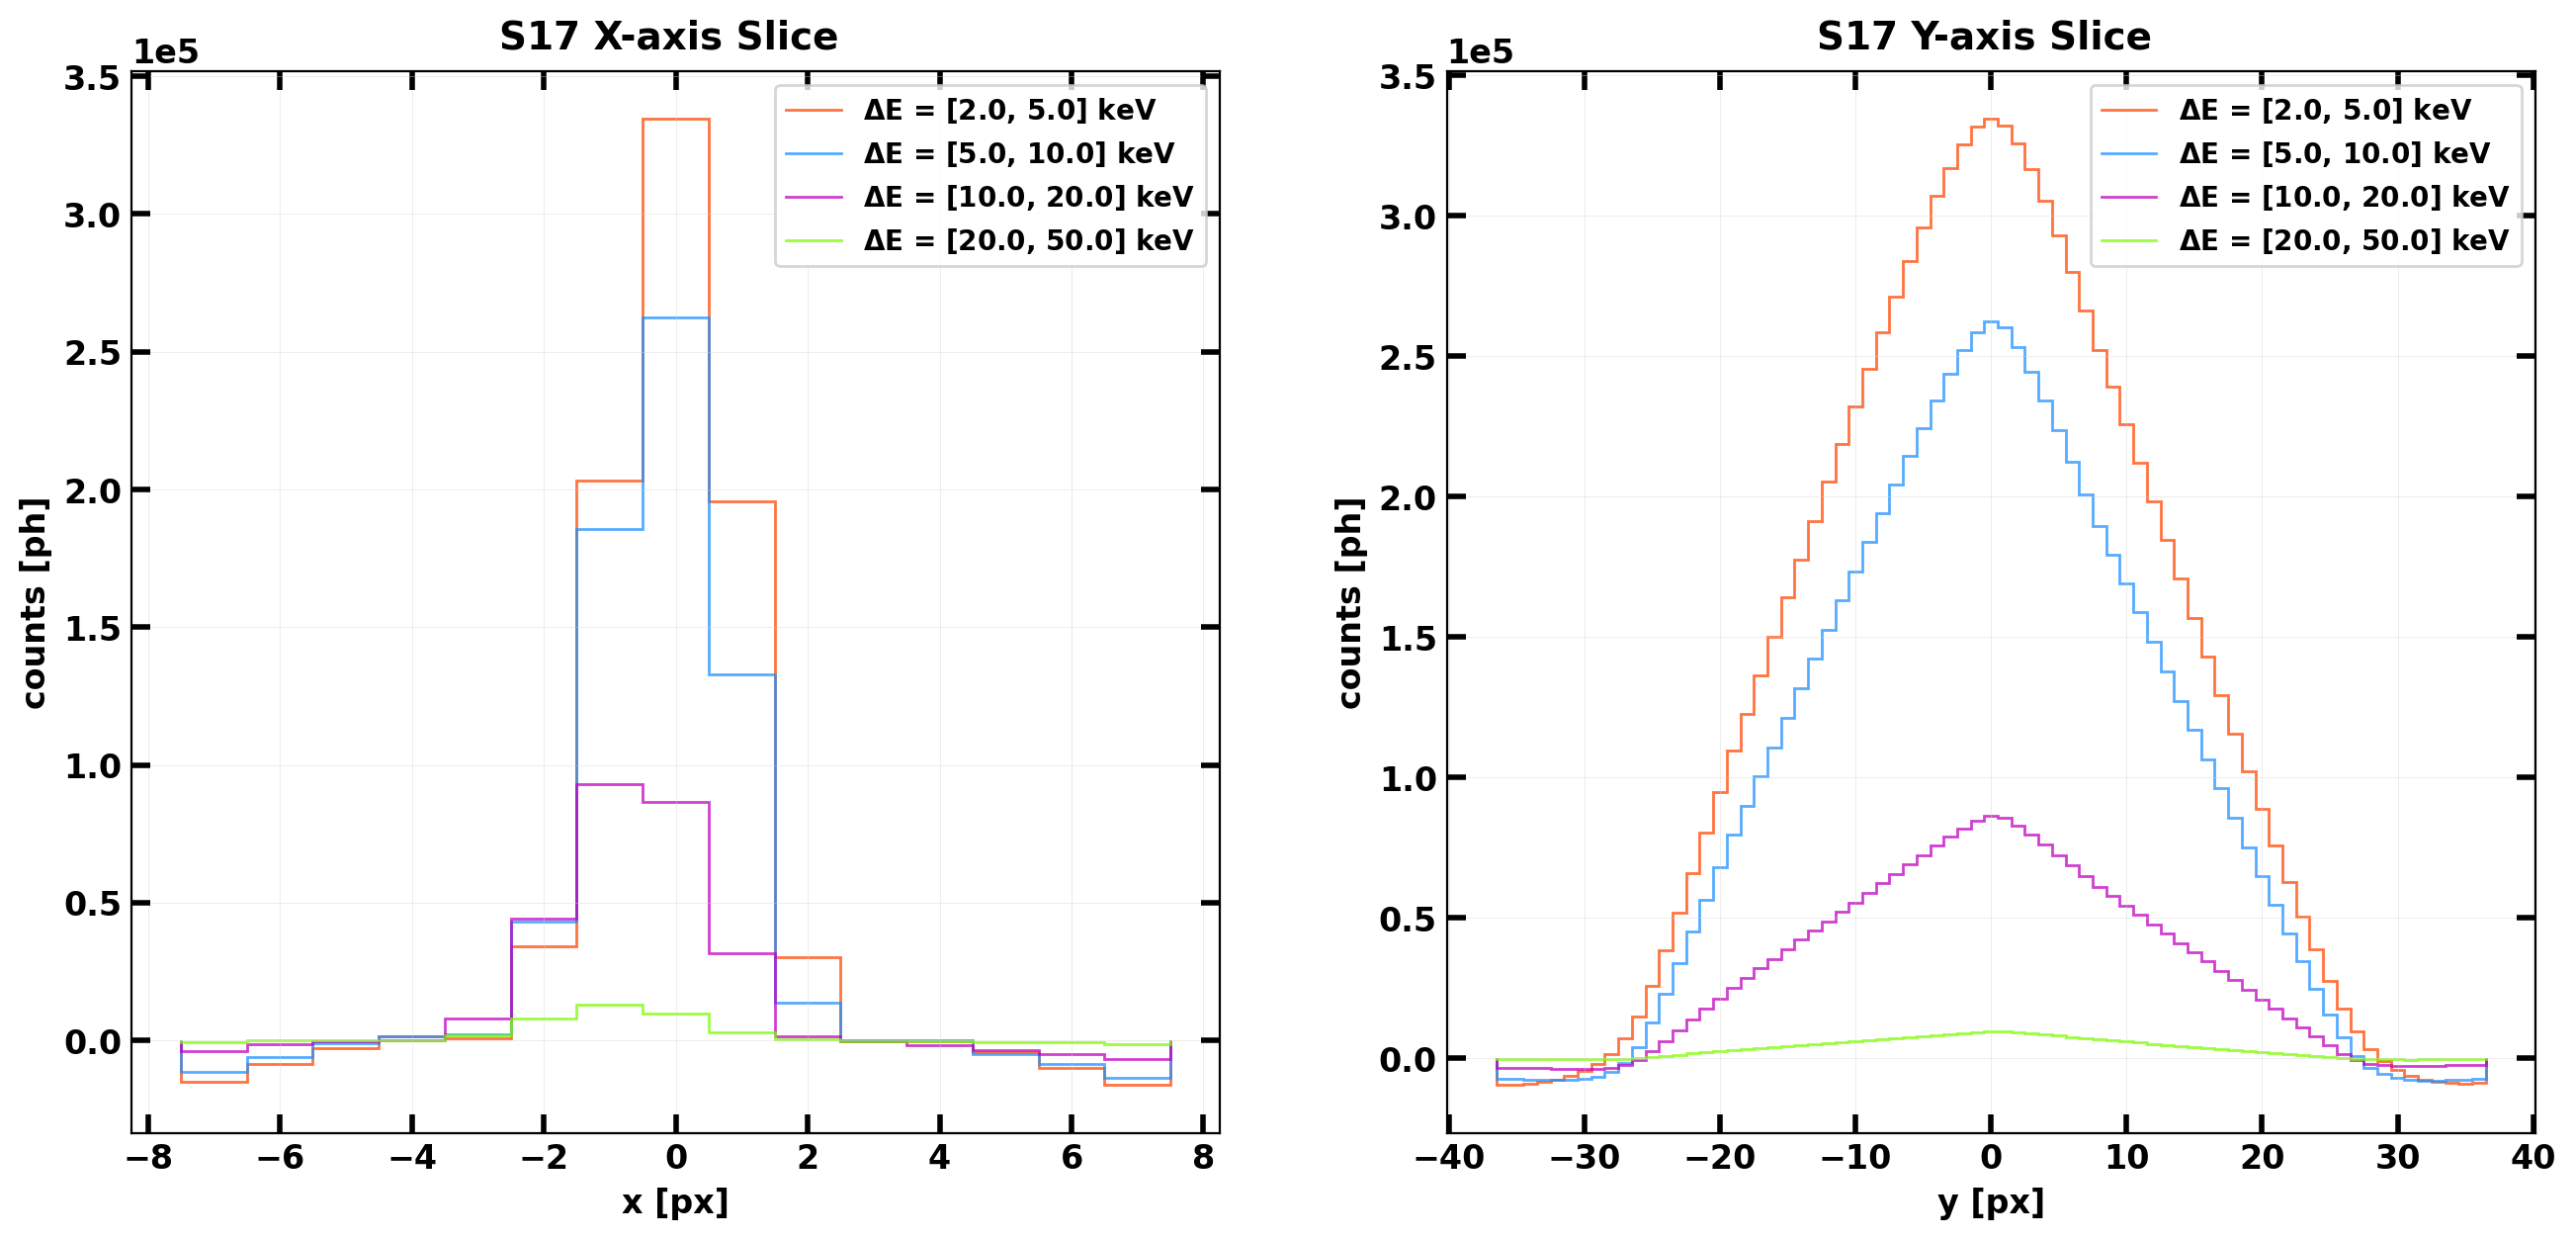

Selected 877999/906779 phs in [2.0, 50.0] keV.


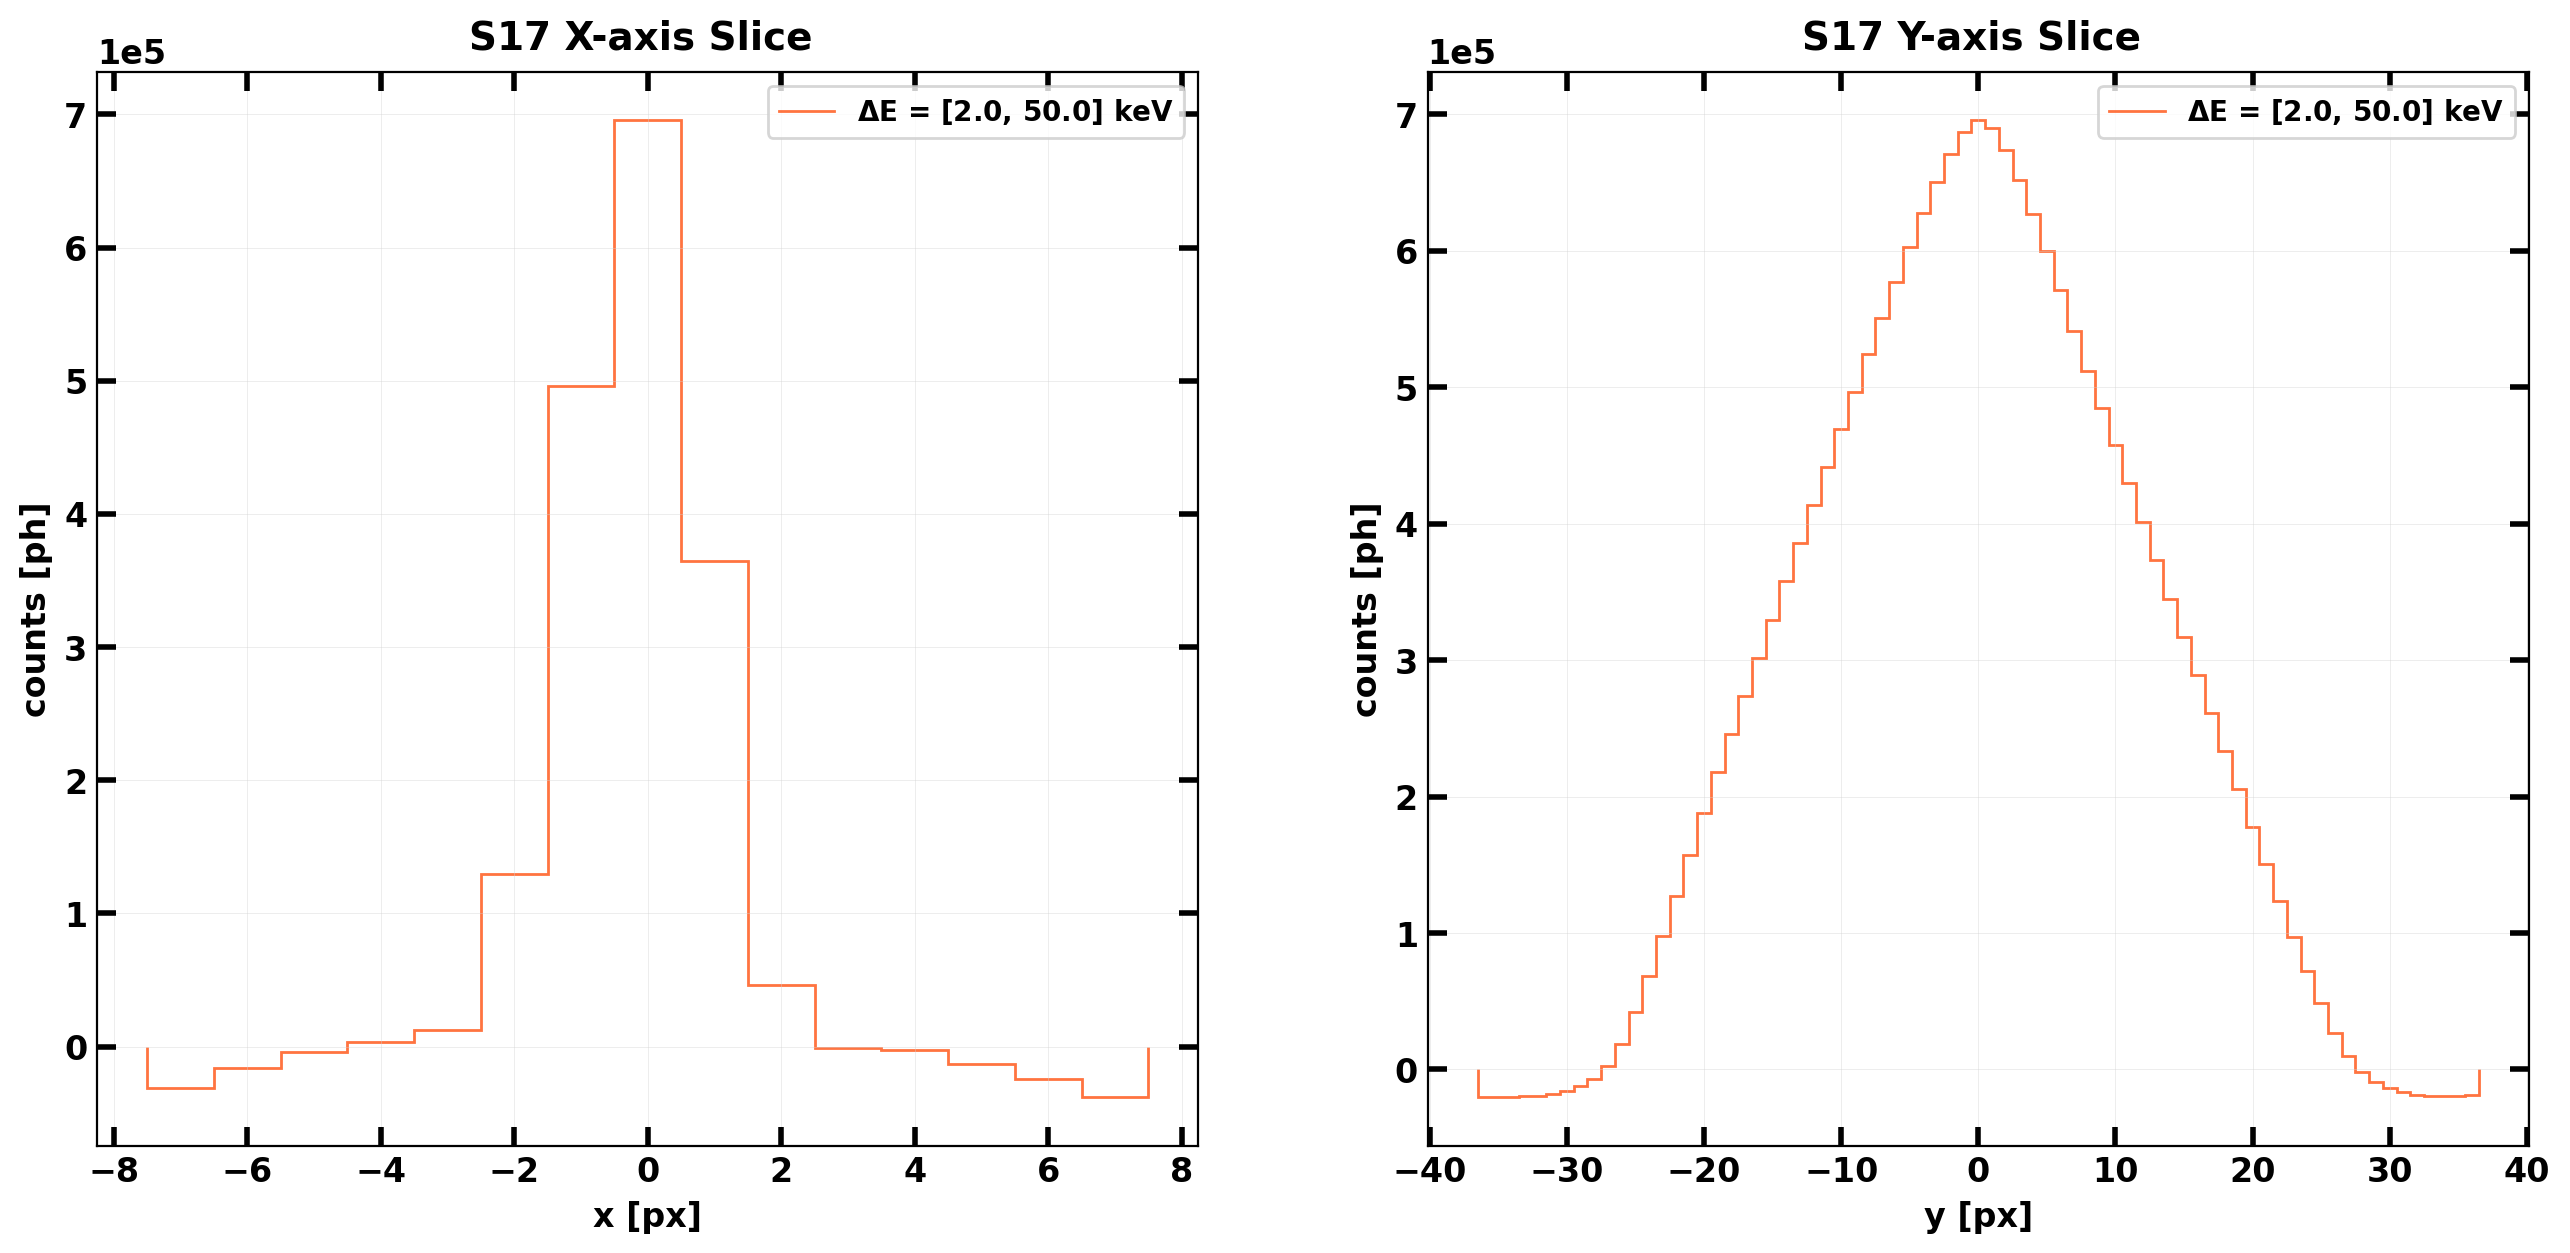

In [11]:
sourceID: str = 's17'

plot_source_psf(sourceID, catalogueA, sdlA, wfm, energy_range)
plot_source_psf(sourceID, catalogueA, sdlA, wfm, (None, None))

Selected 12621/27254 phs in [2.0, 5.0] keV.
Selected 9083/27254 phs in [5.0, 10.0] keV.
Selected 3575/27254 phs in [10.0, 20.0] keV.
Selected 427/27254 phs in [20.0, 50.0] keV.


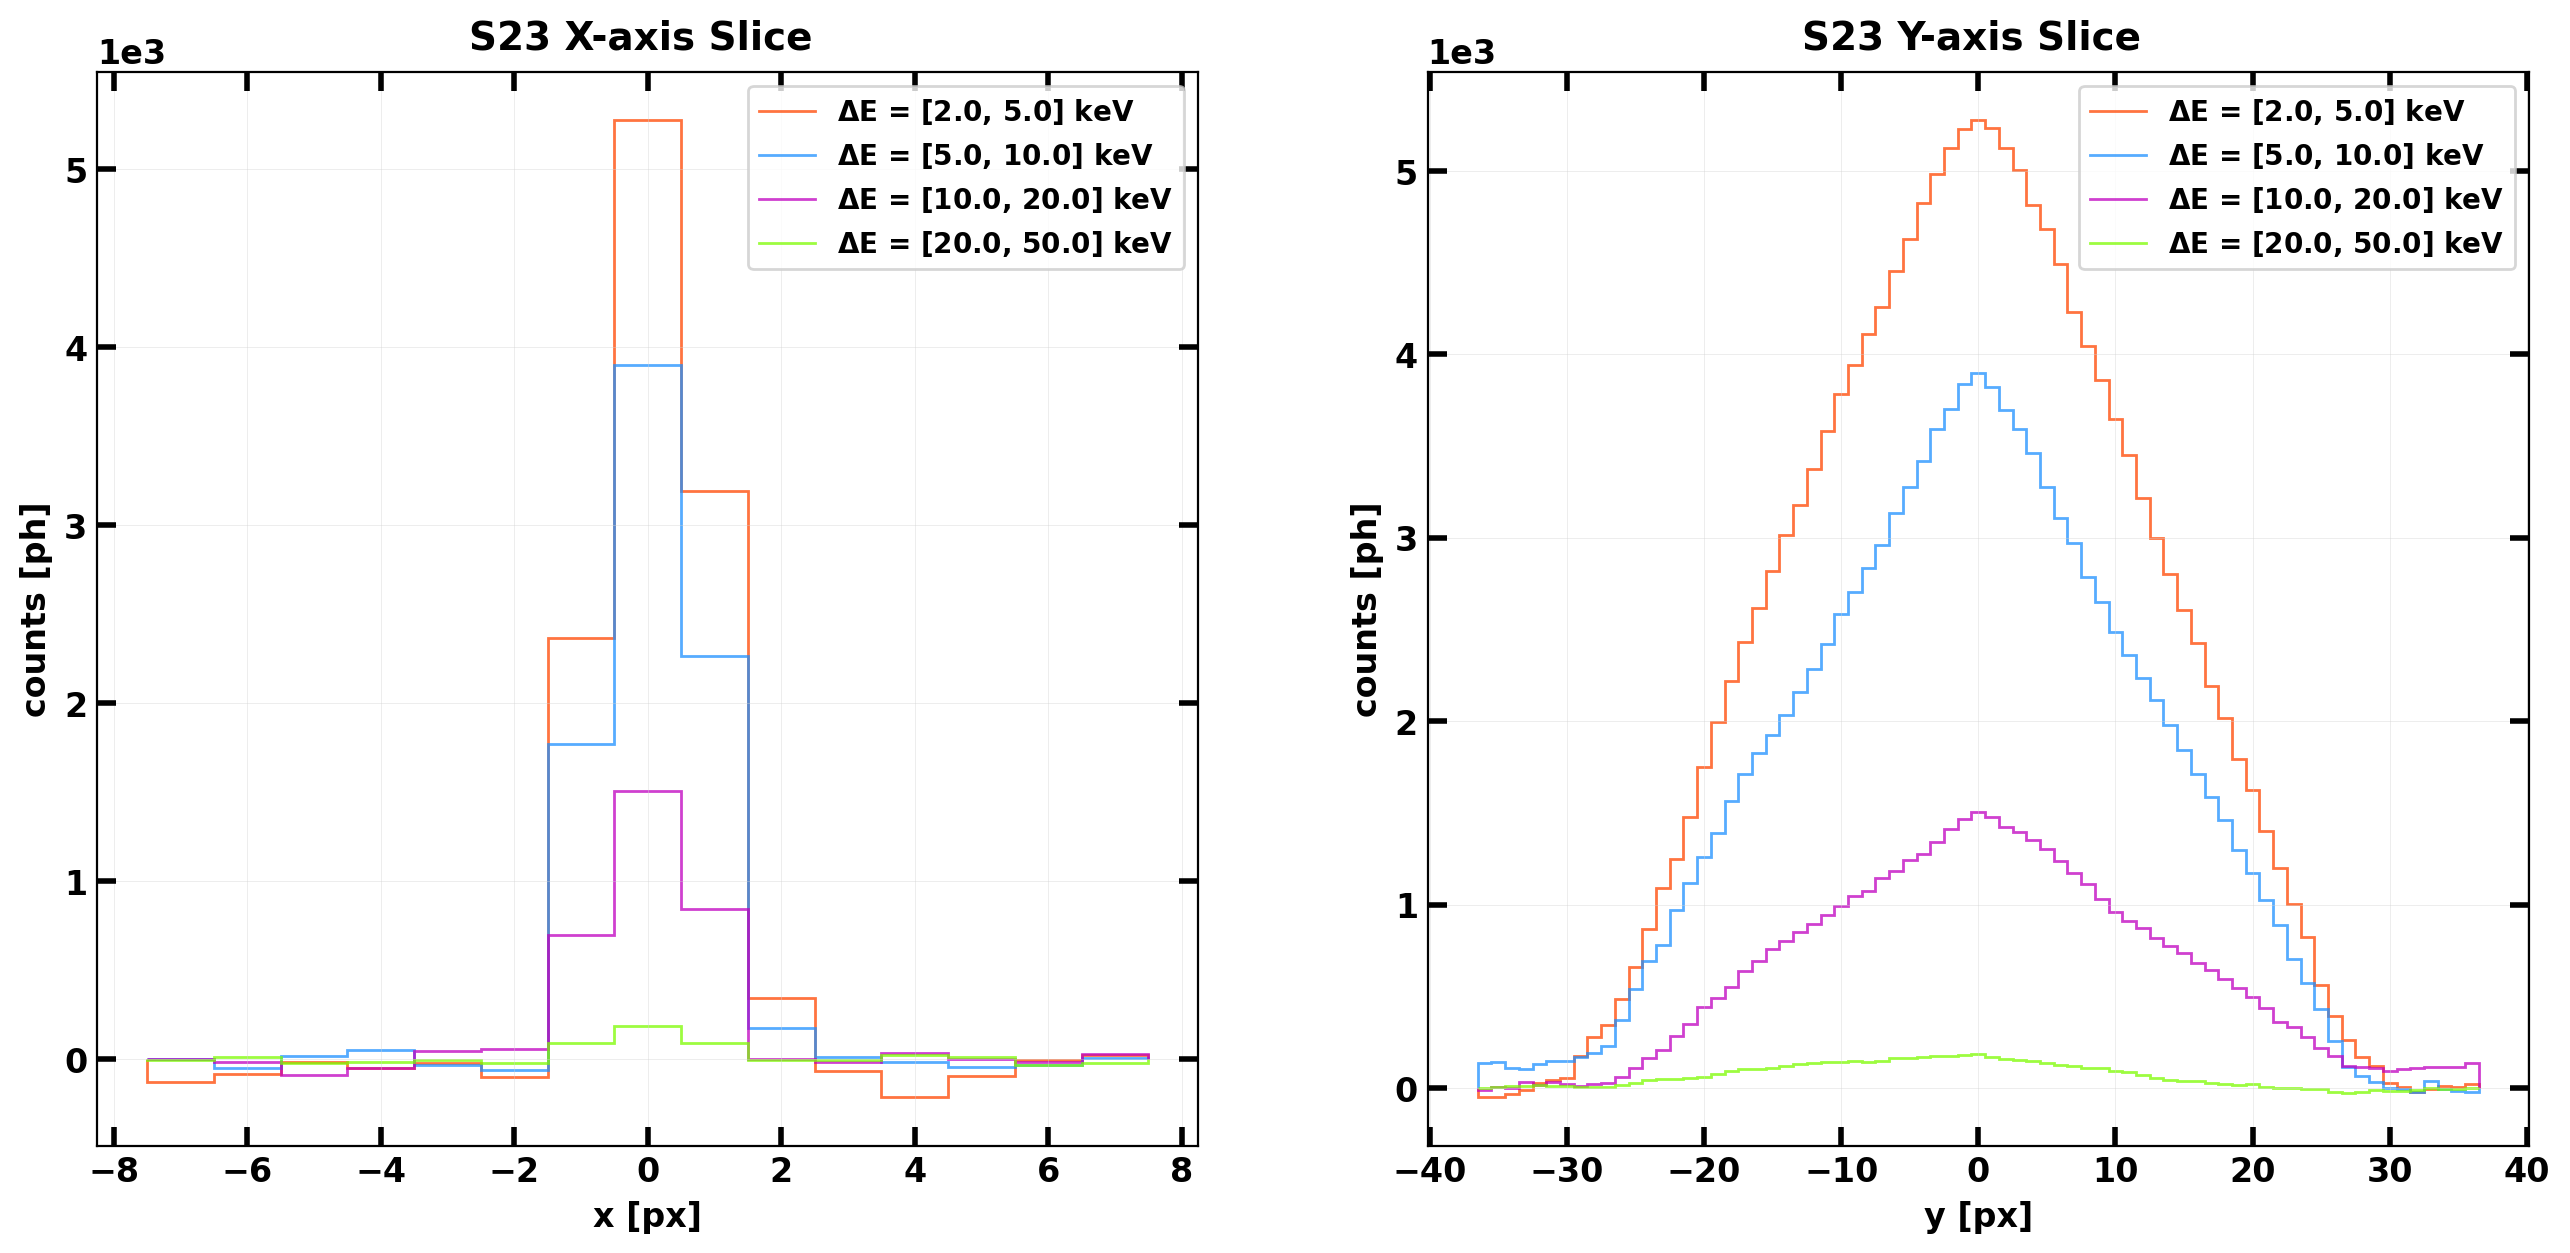

Selected 25823/27254 phs in [2.0, 50.0] keV.


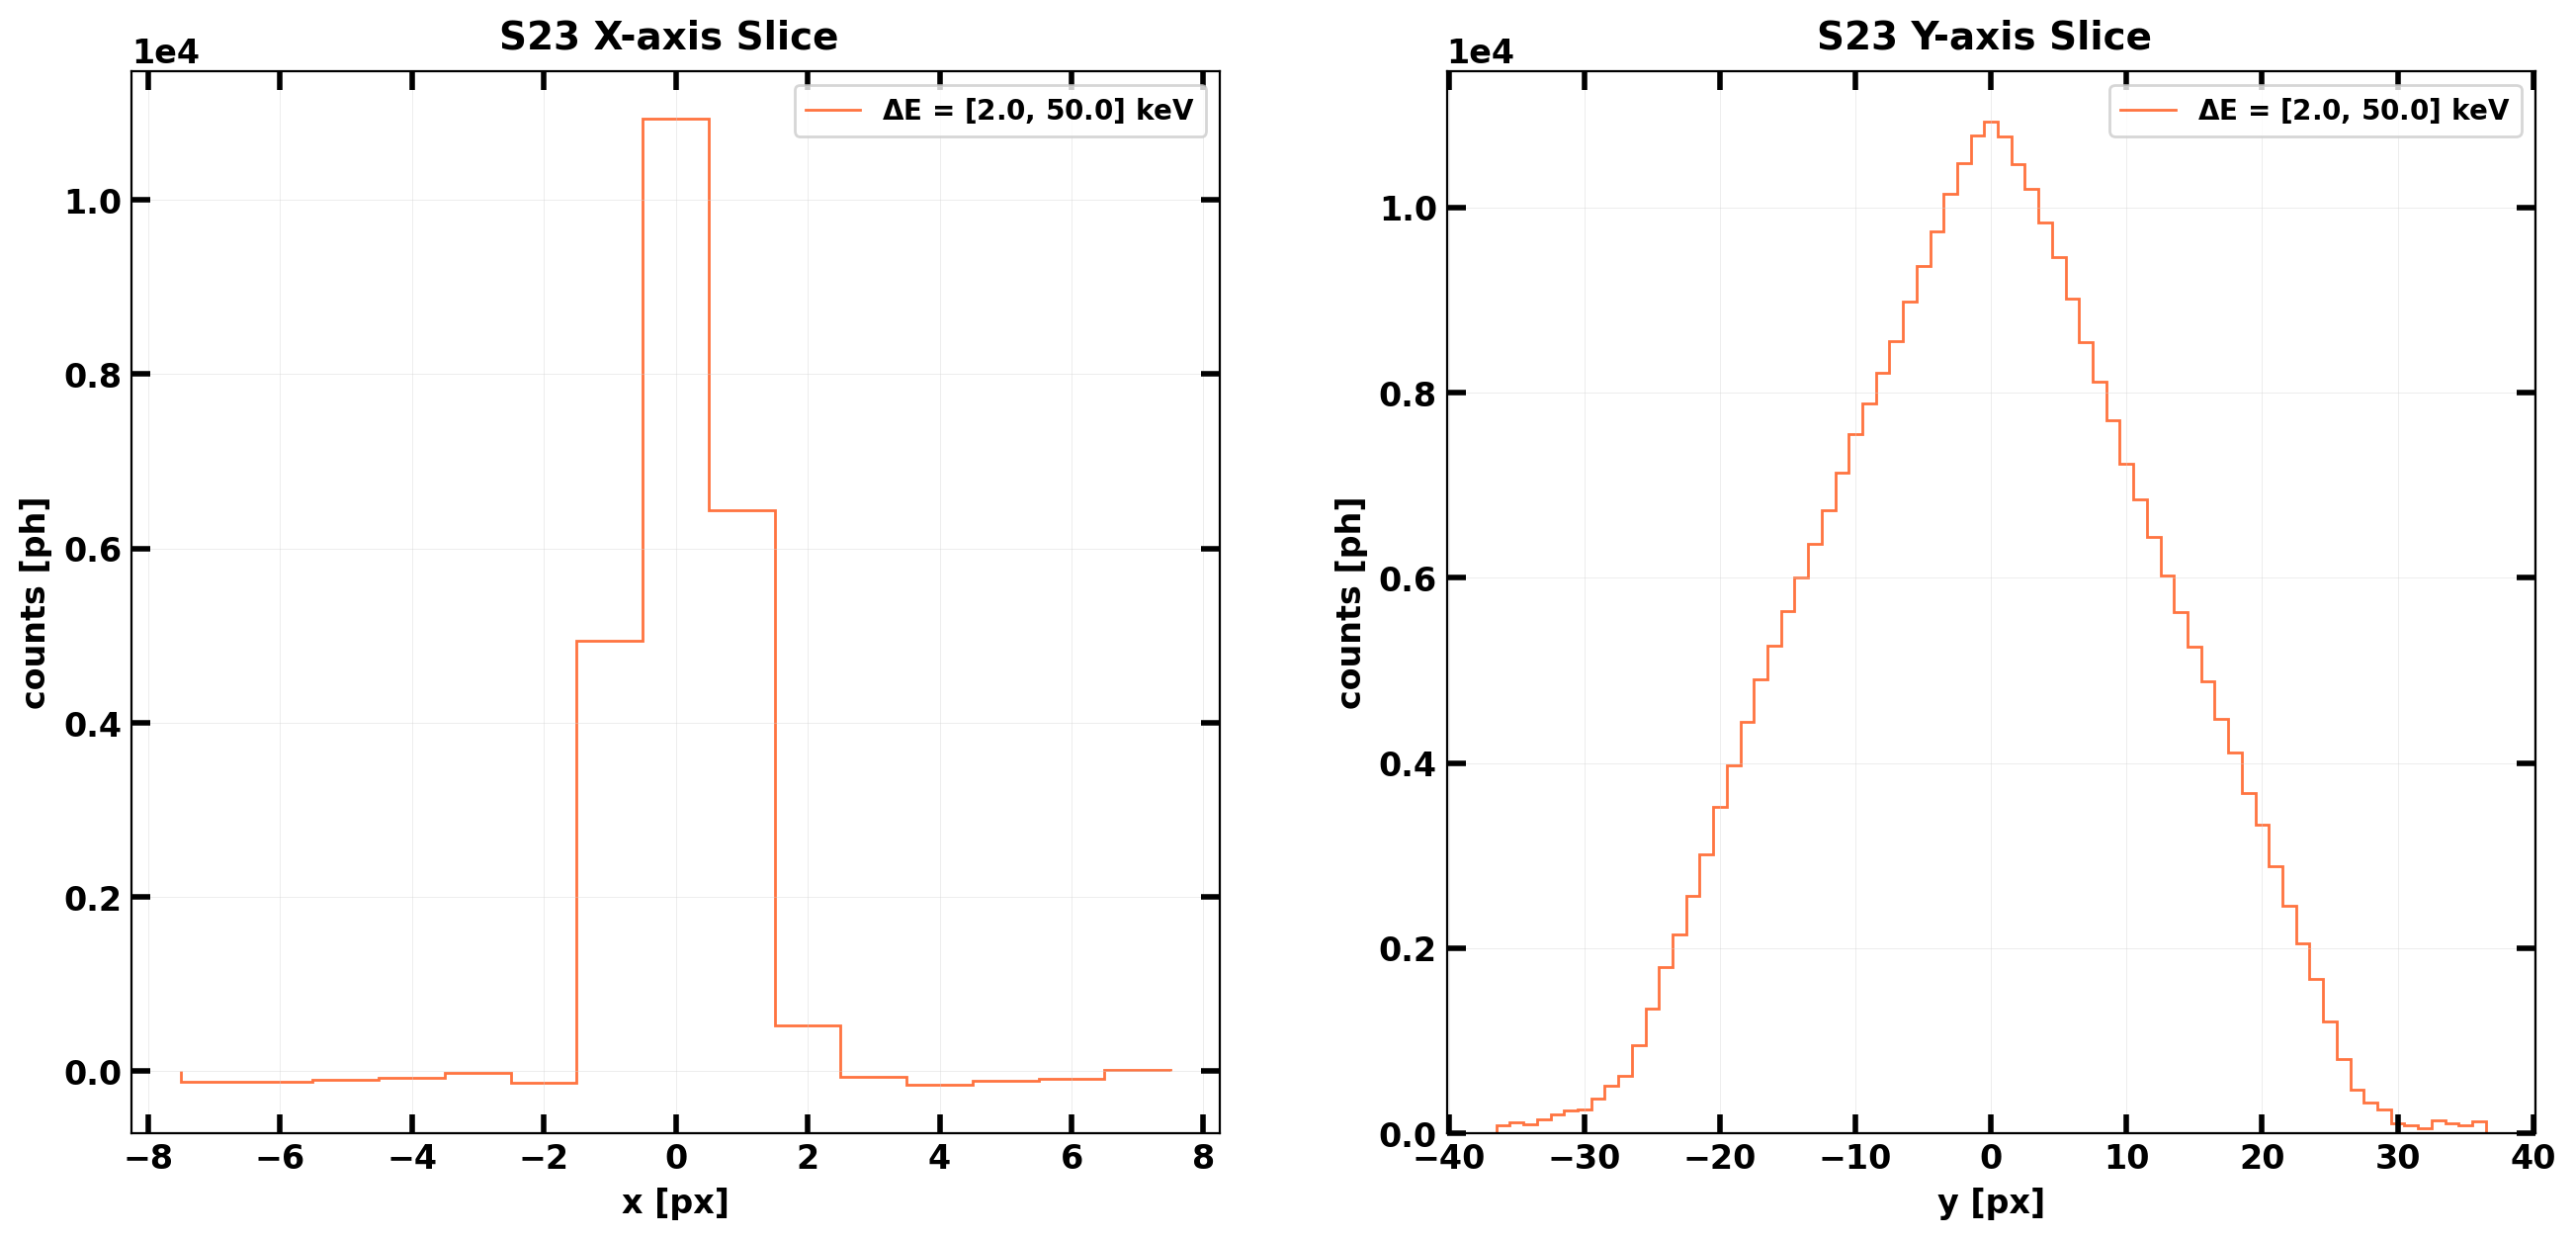

In [7]:
sourceID: str = 's23'

plot_source_psf(sourceID, catalogueA, sdlA, wfm, energy_range)
plot_source_psf(sourceID, catalogueA, sdlA, wfm, (None, None))

# NOTE: ScoX-1 is similar to this source

Selected 21645/50753 phs in [2.0, 5.0] keV.
Selected 17618/50753 phs in [5.0, 10.0] keV.
Selected 7618/50753 phs in [10.0, 20.0] keV.
Selected 1064/50753 phs in [20.0, 50.0] keV.


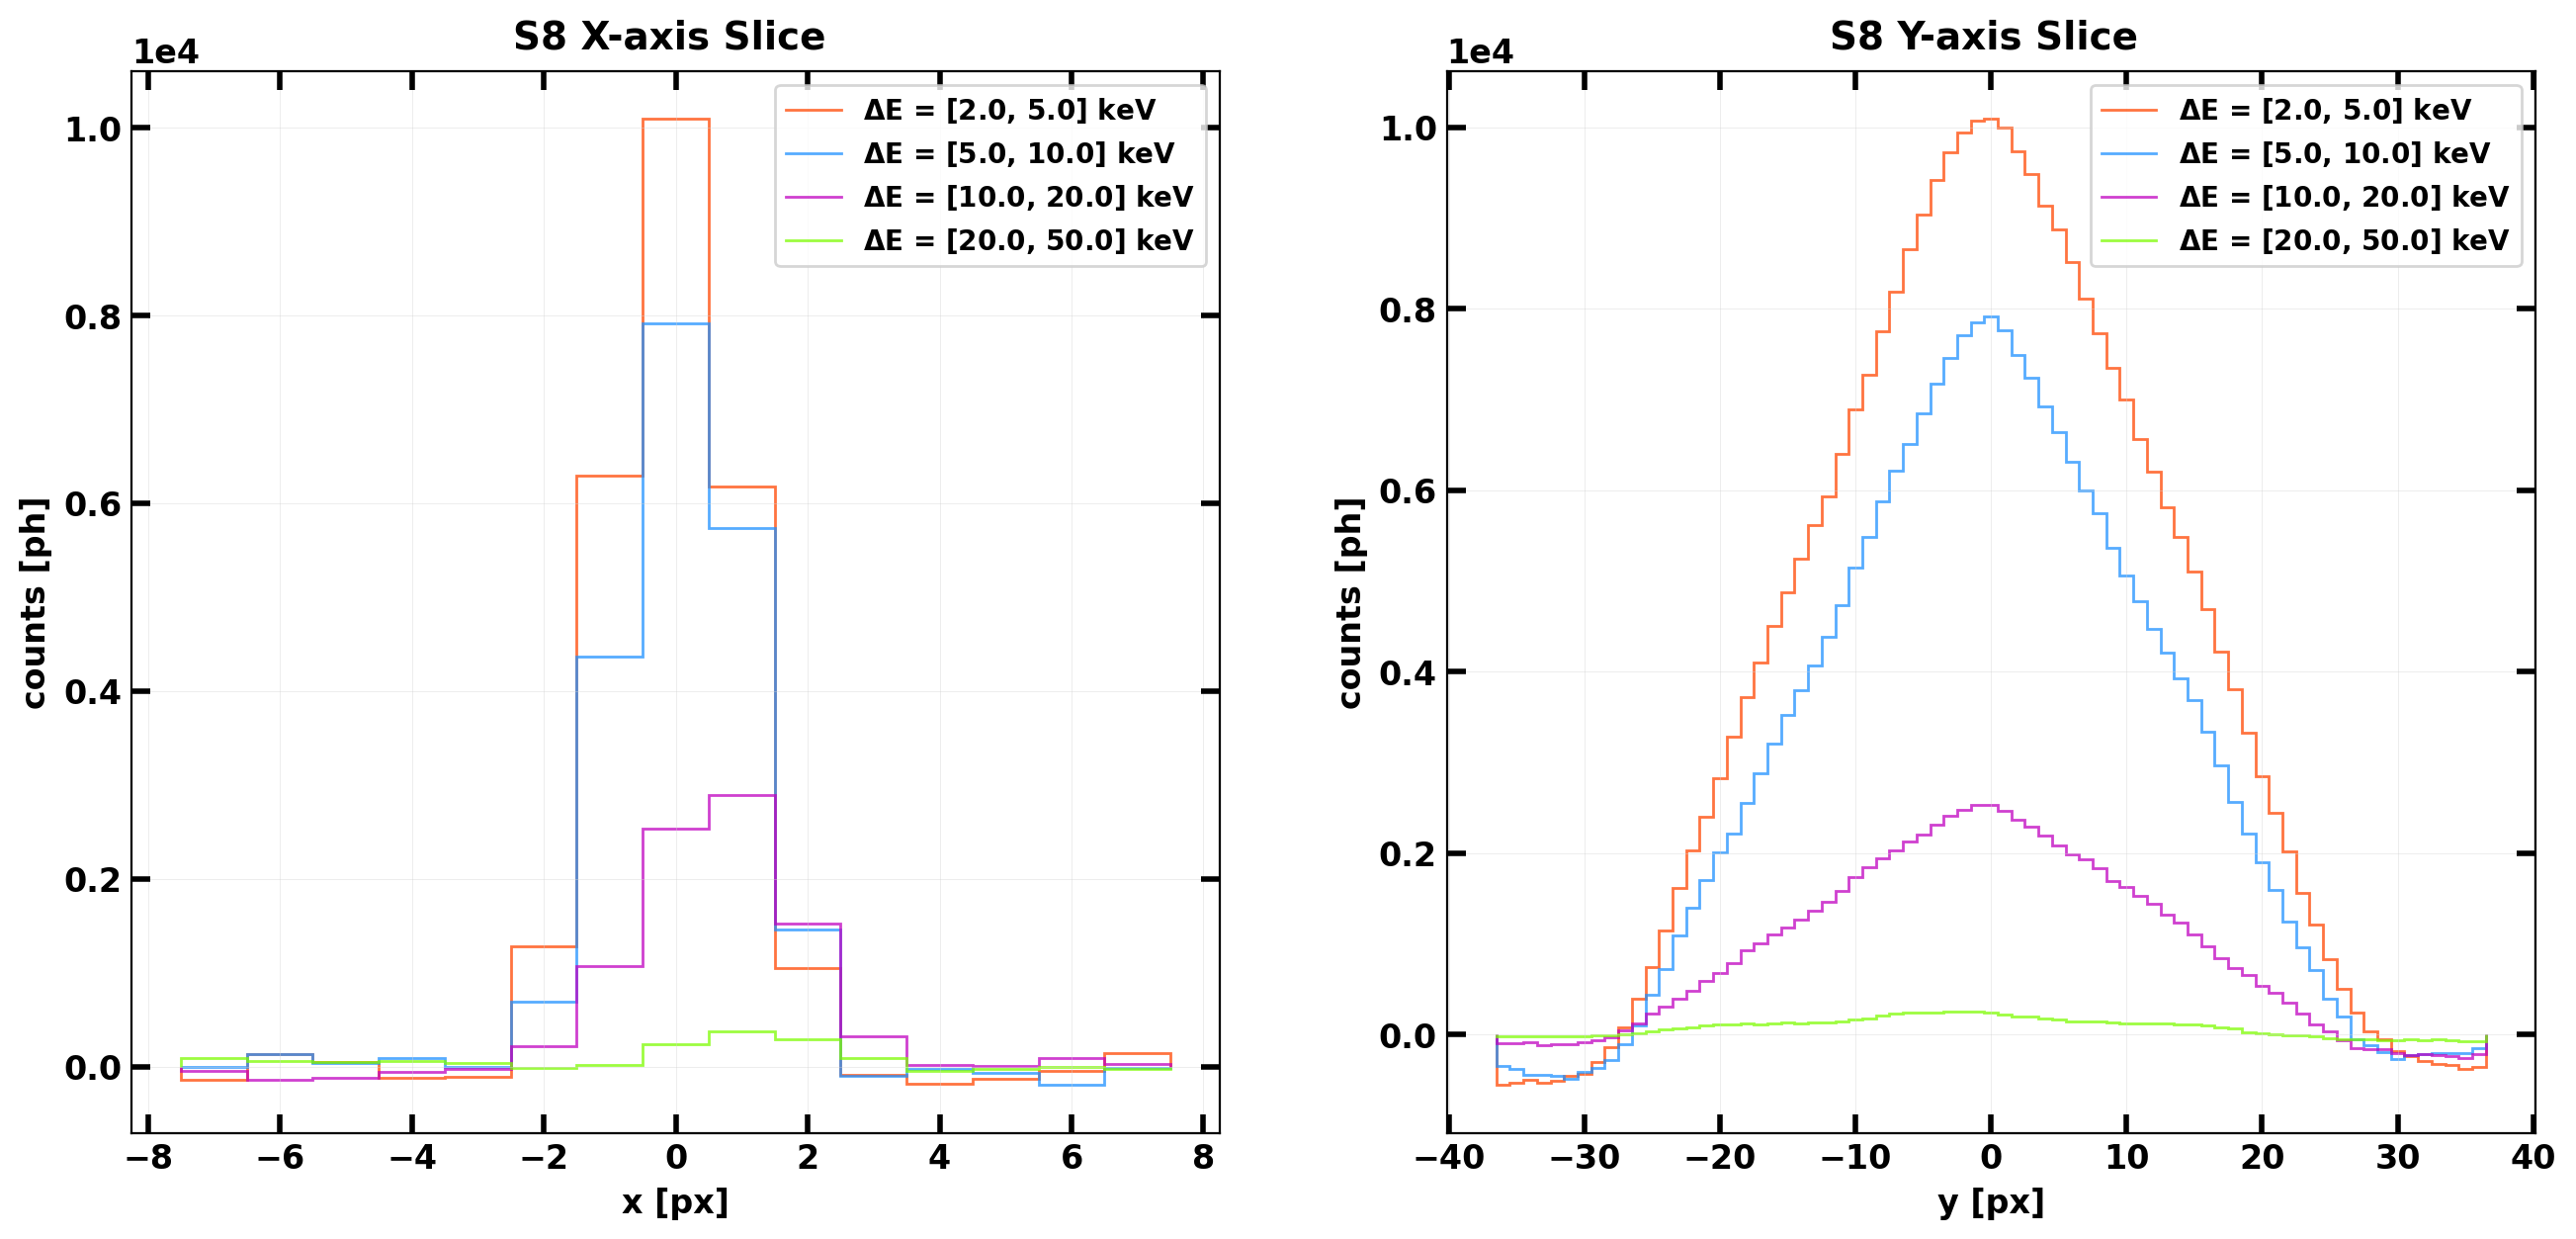

Selected 48124/50753 phs in [2.0, 50.0] keV.


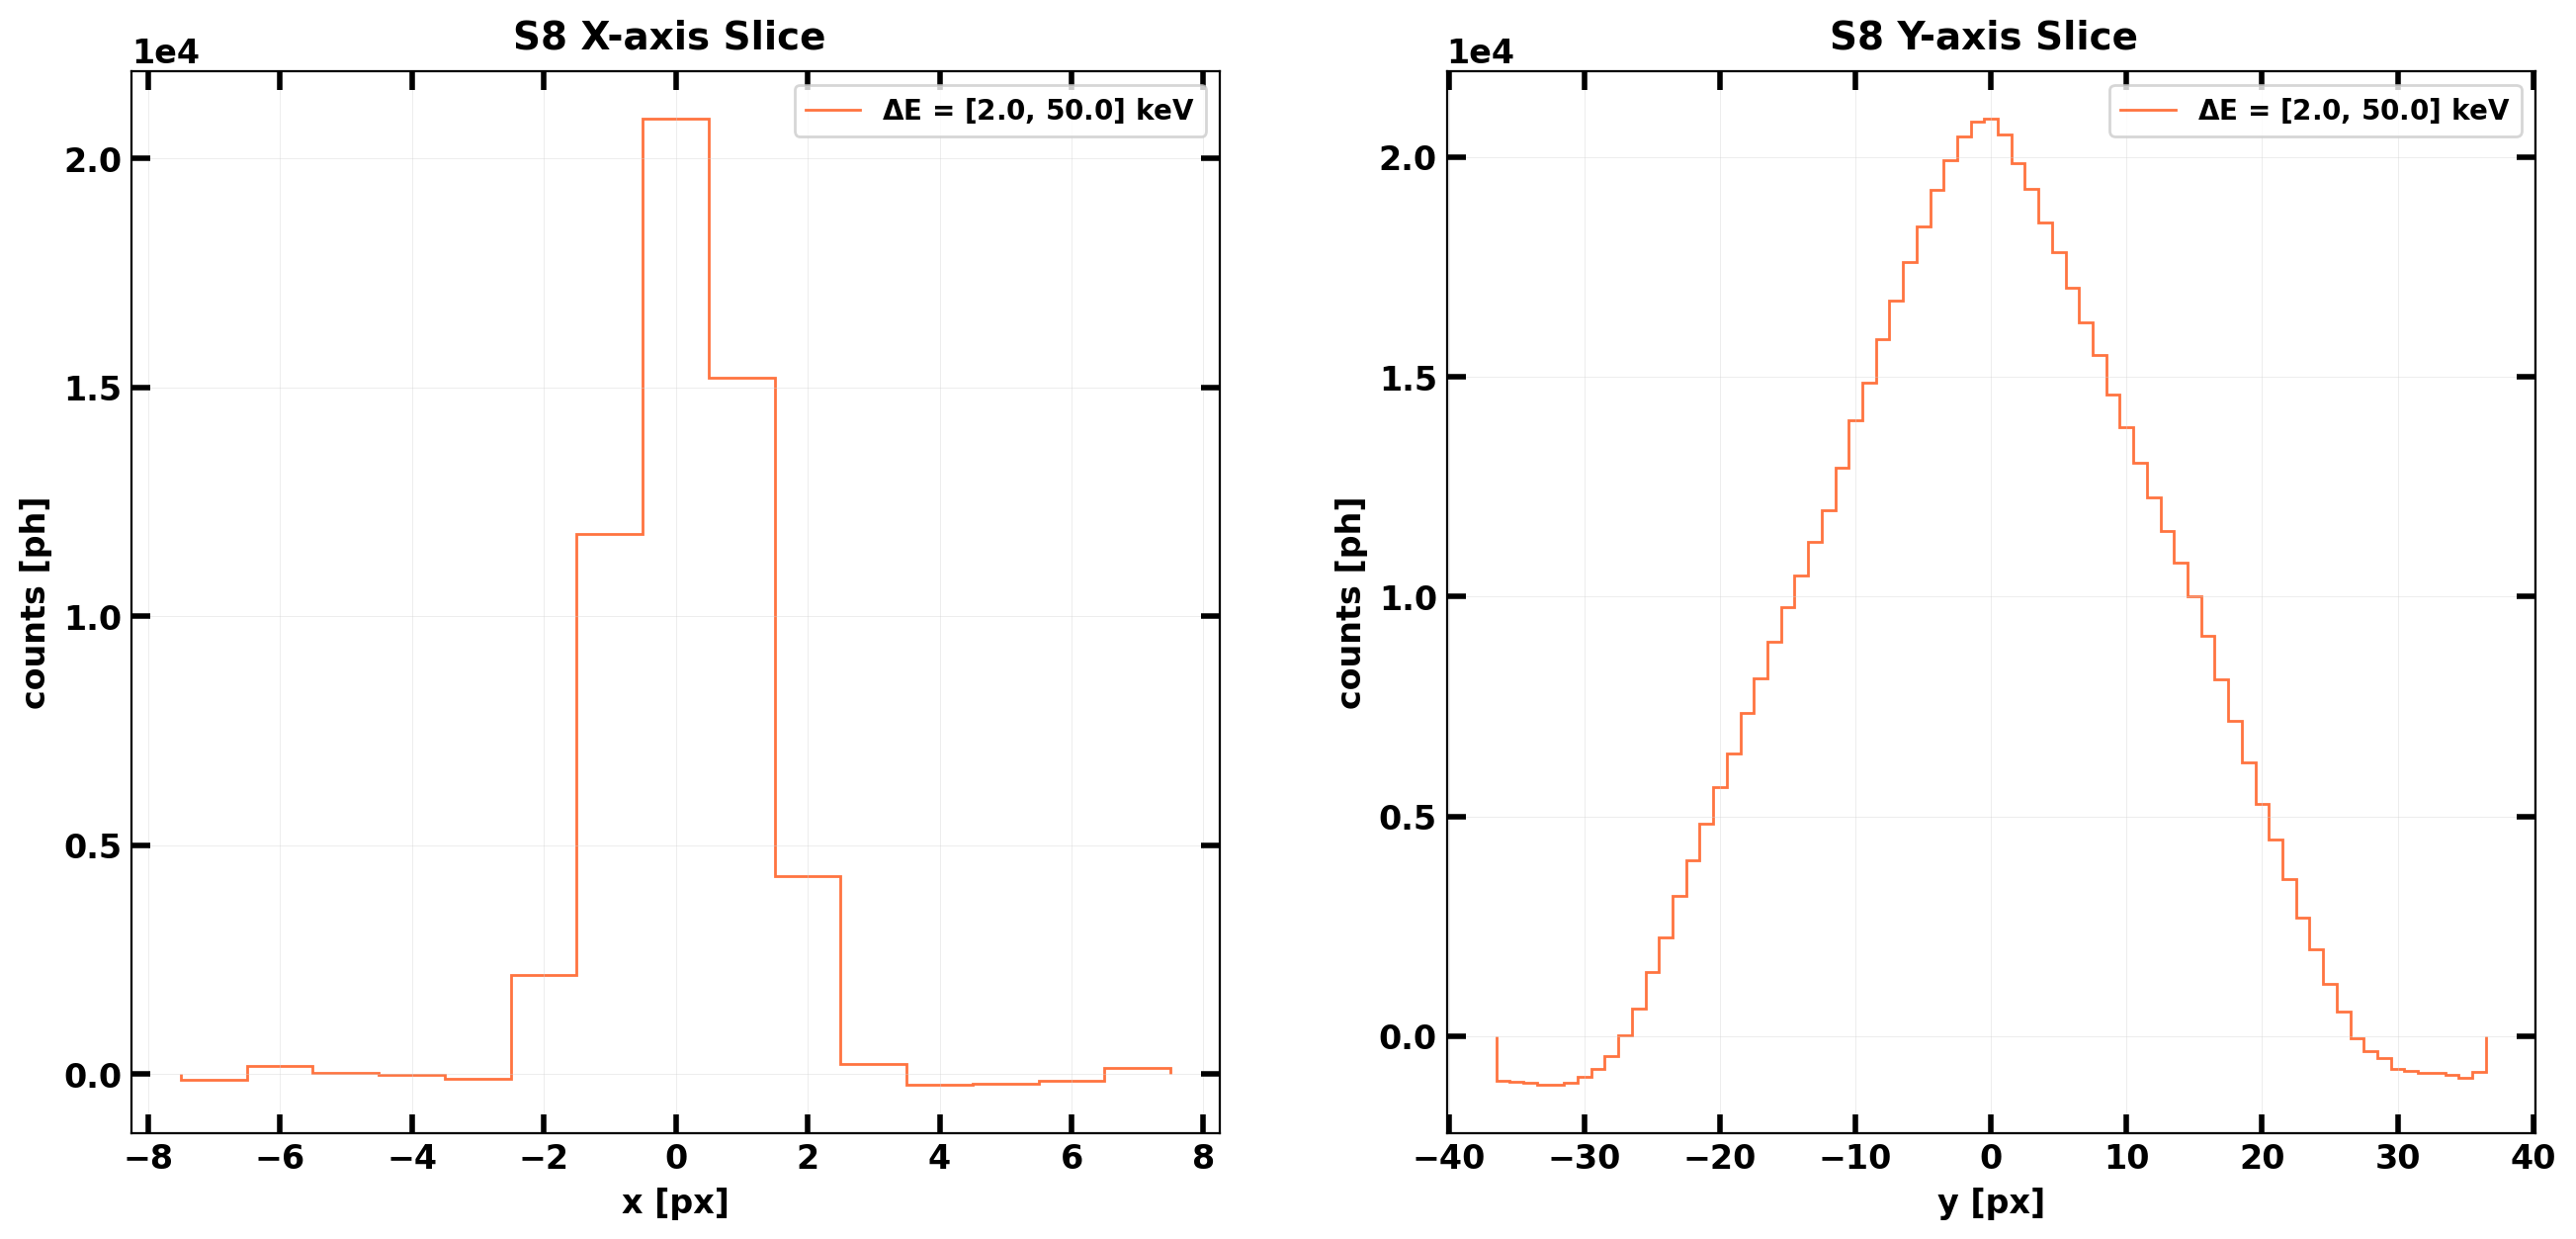

In [8]:
sourceID: str = 's8'

plot_source_psf(sourceID, catalogueA, sdlA, wfm, energy_range)
plot_source_psf(sourceID, catalogueA, sdlA, wfm, (None, None))